In [9]:
!pip install torch torchvision

In [10]:
from __future__ import annotations

import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance
from scipy import stats

import torch
import torch.nn as nn
from torchvision import models, transforms

In [11]:
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'Phase2' else Path.cwd().resolve()
PHASE2_DIR = PROJECT_ROOT / 'Phase2'
DATASET_ROOT = PROJECT_ROOT / 'dataset'
METADATA_PATH = DATASET_ROOT / 'metadata.csv'

OUT_DIR = PHASE2_DIR / 'results_pixel'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD = [0.2023, 0.1994, 0.2010]

IMG_SIZE = 32
TARGET_SPLIT = "test"
TARGET_CLASSES = ["FAKE", "REAL"]
NUM_SAMPLES_PER_CLASS = 24
SEED = 42

In [12]:
def build_resnet18(num_classes=2):
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes),
    )
    return model

def find_checkpoint(project_root: Path) -> Path:
    candidates = [
        project_root / 'Phase1' / 'models' / 'resnet18_subset_best.pt',
        project_root / 'Phase1' / 'cifake_resnet18_final.pt',
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("No checkpoint found.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = find_checkpoint(PROJECT_ROOT)
model = build_resnet18()
state = torch.load(ckpt_path, map_location="cpu")
if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]

model.load_state_dict(state)
model.to(device).eval()

print("Loaded model:", ckpt_path)

Loaded model: D:\batch-hackathon\Phase1\models\resnet18_subset_best.pt


In [13]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

In [14]:
def load_samples():
    meta = pd.read_csv(METADATA_PATH)
    rows = []
    for i, cname in enumerate(TARGET_CLASSES):
        part = meta[(meta["split"] == TARGET_SPLIT) &
                    (meta["label_name"].str.upper() == cname)].copy()
        part = part.sample(n=min(NUM_SAMPLES_PER_CLASS, len(part)),
                           random_state=SEED+i)
        rows.append(part)
    df = pd.concat(rows, ignore_index=True)
    df["class_name"] = df["label_name"].str.upper()
    df["abs_path"] = df["filepath"].map(lambda p: str(DATASET_ROOT / p))
    return df

samples = load_samples()
print("Samples loaded:", len(samples))

Samples loaded: 48


Gaussian Noise

In [15]:
def add_gaussian_noise(img, sigma=0.02):
    arr = np.array(img).astype(np.float32) / 255.0
    noise = np.random.normal(0, sigma, arr.shape)
    arr = np.clip(arr + noise, 0, 1)
    return Image.fromarray((arr*255).astype(np.uint8))

Gaussian Blur

In [16]:
def apply_blur(img, radius=1):
    return img.filter(ImageFilter.GaussianBlur(radius))

JPEG Compression

In [17]:
import io
def jpeg_compress(img, quality=85):
    buffer = io.BytesIO()
    img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer)

Brightness Shift

In [18]:
def adjust_brightness(img, factor=1.05):
    return ImageEnhance.Brightness(img).enhance(factor)

FGSM Attack

In [19]:
def fgsm_attack(pil_img, epsilon=0.005):
    x = transform(pil_img).unsqueeze(0).to(device)
    x.requires_grad = True
    
    output = model(x)
    label = output.argmax(dim=1)
    loss = nn.CrossEntropyLoss()(output, label)
    
    model.zero_grad()
    loss.backward()
    
    perturbed = x + epsilon * x.grad.sign()
    perturbed = torch.clamp(perturbed, -3, 3)
    
    # unnormalize
    mean = torch.tensor(CIFAR_MEAN).view(1,3,1,1).to(device)
    std = torch.tensor(CIFAR_STD).view(1,3,1,1).to(device)
    
    img = perturbed * std + mean
    img = torch.clamp(img, 0, 1)
    
    img = img.squeeze().detach().cpu()
    return transforms.ToPILImage()(img)

Prediction

In [20]:
def predict_p_fake(pil_img):
    x = transform(pil_img).unsqueeze(0).to(device)
    with torch.inference_mode():
        probs = torch.softmax(model(x), dim=1)[0]
    return float(probs[1])

Main Experiment Loop

In [21]:
results = []

for i, row in samples.iterrows():
    img = Image.open(row["abs_path"]).convert("RGB")
    sample_id = f"{row['class_name']}_{i:03d}"
    
    variants = {
        "original": img,
        "gaussian_noise": add_gaussian_noise(img),
        "blur": apply_blur(img),
        "jpeg85": jpeg_compress(img),
        "brightness+5": adjust_brightness(img),
        "fgsm": fgsm_attack(img)
    }
    
    for stage, variant_img in variants.items():
        p_fake = predict_p_fake(variant_img)
        
        results.append({
            "sample_id": sample_id,
            "class_name": row["class_name"],
            "stage": stage,
            "p_fake": p_fake
        })

In [22]:
df = pd.DataFrame(results)
df.to_csv(OUT_DIR / "pixel_confidence_progression.csv", index=False)

summary = df.groupby("stage")["p_fake"].agg(["mean","std","count"]).reset_index()
summary["sem"] = summary["std"] / np.sqrt(summary["count"])
summary.to_csv(OUT_DIR / "pixel_confidence_summary.csv", index=False)

print(summary)

            stage      mean       std  count       sem
0            blur  0.414884  0.119160     48  0.017199
1    brightness+5  0.494419  0.123589     48  0.017839
2            fgsm  0.496272  0.083992     48  0.012123
3  gaussian_noise  0.495131  0.115788     48  0.016713
4          jpeg85  0.493861  0.111299     48  0.016065
5        original  0.497360  0.118009     48  0.017033


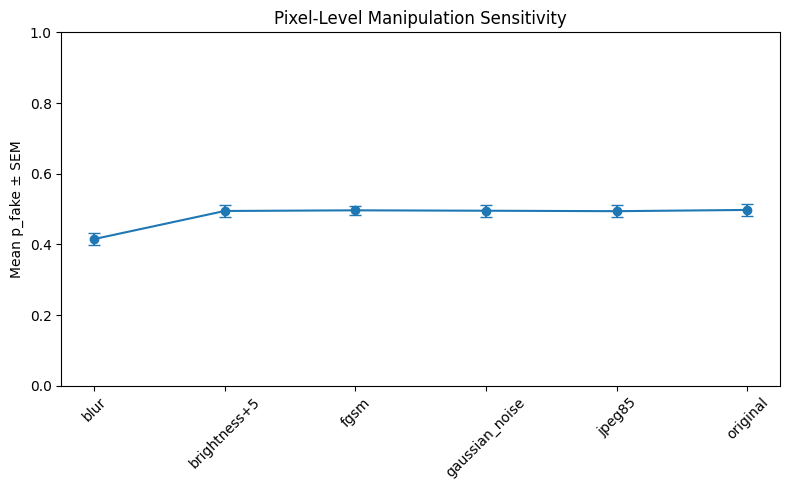

In [23]:
plt.figure(figsize=(8,5))
plt.errorbar(summary["stage"],
             summary["mean"],
             yerr=summary["sem"],
             marker="o",
             capsize=4)

plt.ylim(0,1)
plt.ylabel("Mean p_fake ± SEM")
plt.title("Pixel-Level Manipulation Sensitivity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR / "pixel_confidence_plot.png", dpi=180)
plt.show()